In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.pipeline import Pipeline

# Classification
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    RandomForestRegressor, GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression

# Metriques
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score
)


# SHAP
try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP disponible")
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP non installe -- pip install shap")


SHAP non installe -- pip install shap
Optuna non installe -- pip install optuna

Imports reussis.



#  MODULE 2 : Modélisation Supervisée

## Partie 1 : Préparation des Données — Split 70 / 15 / 15 (stratifié)

> **Ratio** : 70% Train | 15% Validation | 15% Test  
> **Stratification** sur `Categorie` pour préserver la distribution des classes.  
> Le **set de validation** sert au tuning, le **test** à l'évaluation finale.

In [18]:
feature_cols = ['Poids', 'Volume','Opacite','Conductivite']

In [19]:
df_clean = df_clean.drop_duplicates(subset=feature_cols, keep='first')

In [ ]:
feature_cols = [c for c in df_clean.columns if c not in [
    'Categorie',        
    'Rapport_Collecte', 
    'Prix_Revente'
]]
X = df_clean[feature_cols].copy()
y = df_clean['Categorie'].copy()


# 1. SPLIT d'abord (sur données brutes)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nSplit terminé:")
print(f"  Train : {X_train.shape}")
print(f"  Val   : {X_val.shape}")
print(f"  Test  : {X_test.shape}")

# 2. SCALE ensuite (fit uniquement sur TRAIN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\n Standardisation terminée (fit sur Train uniquement)")
print(f"  Train mean: {X_train_scaled.mean():.2e}")
print(f"  Test mean:  {X_test_scaled.mean():.2e}")


Split terminé:
  Train : (1652, 6)
  Val   : (354, 6)
  Test  : (355, 6)

✅ Standardisation terminée (fit sur Train uniquement)
  Train mean: -8.78e-18
  Test mean:  3.04e-02



## Partie 2 : Classification — Entrainement et Evaluation

### 2.1 — Random Forest

In [21]:
print("\n=== RANDOM FOREST ===")

model_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_split=10,
    random_state=42
)

model_rf.fit(X_train_scaled, y_train)

y_val_rf = model_rf.predict(X_val_scaled)
print(f"[Val] Accuracy: {accuracy_score(y_val, y_val_rf):.4f}")

y_pred_rf = model_rf.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_rec = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f"[Test] Random Forest — Acc: {rf_acc:.4f} | F1: {rf_f1:.4f}")
print("\n", classification_report(y_test, y_pred_rf, zero_division=0))

# CV sur train
cv_rf = cross_val_score(model_rf, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"CV RF (5 folds) : {cv_rf.round(3)} -> mu={cv_rf.mean():.3f} +/- {cv_rf.std():.3f}")


=== RANDOM FOREST ===
[Val] Accuracy: 0.9887
[Test] Random Forest — Acc: 0.9859 | F1: 0.9859

               precision    recall  f1-score   support

           0       0.99      1.00      0.99        66
           1       0.96      0.99      0.97        78
           2       0.99      0.97      0.98       119
           3       1.00      1.00      1.00        92

    accuracy                           0.99       355
   macro avg       0.98      0.99      0.99       355
weighted avg       0.99      0.99      0.99       355

CV RF (5 folds) : [0.991 0.997 0.964 0.991 0.997] -> mu=0.988 +/- 0.012


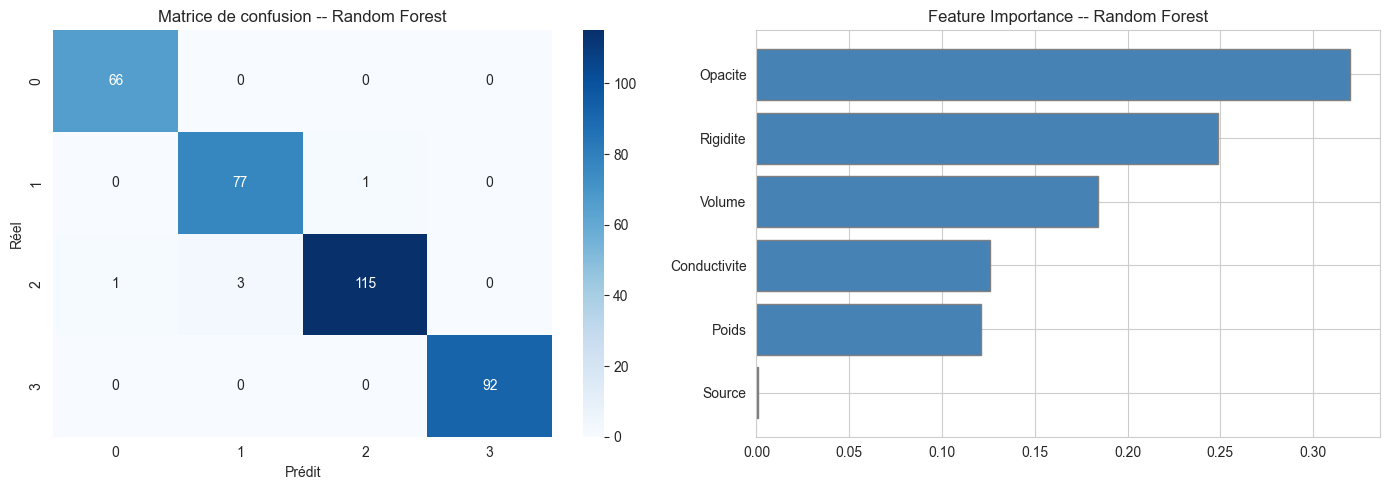

CV RF (5 folds) : [0.991 0.997 0.964 0.991 0.997] -> mu=0.988 +/- 0.012


In [22]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d',
            cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Prédit')
axes[0].set_ylabel('Réel')
axes[0].set_title('Matrice de confusion -- Random Forest')

importance_rf = pd.DataFrame({
    'Feature': feature_cols,  
    'Importance': model_rf.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(importance_rf['Feature'], importance_rf['Importance'],
             color='steelblue', edgecolor='grey')
axes[1].set_title('Feature Importance -- Random Forest')

plt.tight_layout()
plt.show()

# Cross-validation sur les données scalées
cv_rf = cross_val_score(model_rf, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"CV RF (5 folds) : {cv_rf.round(3)} -> mu={cv_rf.mean():.3f} +/- {cv_rf.std():.3f}")

### 2.2 — Gradient Boosting Classifier

In [23]:

print("\n=== GRADIENT BOOSTING ===")

gbc = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbc.fit(X_train_scaled, y_train) 

y_val_gbc = gbc.predict(X_val_scaled)  
y_pred_gbc = gbc.predict(X_test_scaled)  

gbc_acc = accuracy_score(y_test, y_pred_gbc)
gbc_prec = precision_score(y_test, y_pred_gbc, average='weighted', zero_division=0)
gbc_rec = recall_score(y_test, y_pred_gbc, average='weighted', zero_division=0)
gbc_f1 = f1_score(y_test, y_pred_gbc, average='weighted', zero_division=0)

print(f"[Val]  Accuracy: {accuracy_score(y_val, y_val_gbc):.4f}")
print(f"[Test] GBC -- Acc: {gbc_acc:.4f} | Prec: {gbc_prec:.4f} | Rec: {gbc_rec:.4f} | F1: {gbc_f1:.4f}")
print("\n", classification_report(y_test, y_pred_gbc, zero_division=0))


=== GRADIENT BOOSTING ===
[Val]  Accuracy: 0.9774
[Test] GBC -- Acc: 0.9944 | Prec: 0.9944 | Rec: 0.9944 | F1: 0.9944

               precision    recall  f1-score   support

           0       0.99      1.00      0.99        66
           1       1.00      0.99      0.99        78
           2       0.99      0.99      0.99       119
           3       1.00      1.00      1.00        92

    accuracy                           0.99       355
   macro avg       0.99      0.99      0.99       355
weighted avg       0.99      0.99      0.99       355



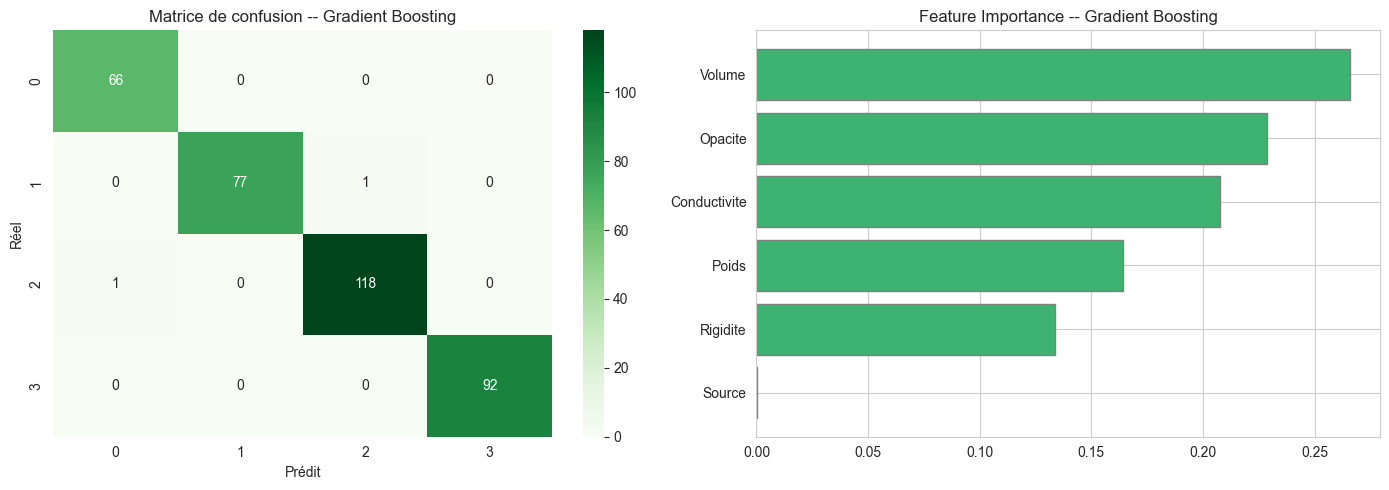

CV GBC (5 folds) : [0.991 0.997 0.979 0.997 0.991] -> mu=0.991 +/- 0.007


In [24]:
# ========== MATRICE DE CONFUSION ET IMPORTANCE GBC ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_gbc), annot=True, fmt='d',
            cmap='Greens', ax=axes[0])
axes[0].set_xlabel('Prédit')
axes[0].set_ylabel('Réel')
axes[0].set_title('Matrice de confusion -- Gradient Boosting')

importance_gbc = pd.DataFrame({
    'Feature': feature_cols, 
    'Importance': gbc.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(importance_gbc['Feature'], importance_gbc['Importance'],
             color='mediumseagreen', edgecolor='grey')
axes[1].set_title('Feature Importance -- Gradient Boosting')

plt.tight_layout()
plt.show()

cv_gbc = cross_val_score(gbc, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"CV GBC (5 folds) : {cv_gbc.round(3)} -> mu={cv_gbc.mean():.3f} +/- {cv_gbc.std():.3f}")

### 2.3 — k-NN (k optimé sur la validation)

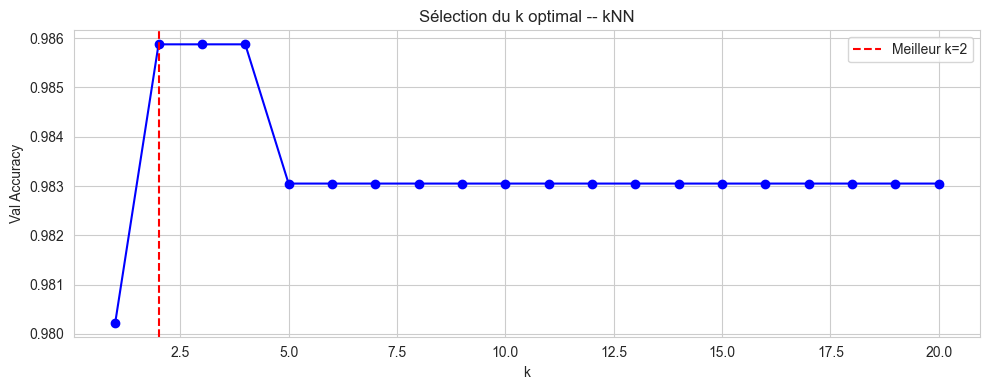

[Test] kNN (k=2) -- Acc: 0.9746 | Prec: 0.9759 | Rec: 0.9746 | F1: 0.9747


In [25]:
# ========== KNN - RECHERCHE DU MEILLEUR k ==========
k_scores = {}

for k in range(1, 21):
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_scaled, y_train) 
    k_scores[k] = accuracy_score(y_val, knn_tmp.predict(X_val_scaled))

best_k = max(k_scores, key=k_scores.get)

plt.figure(figsize=(10, 4))
plt.plot(list(k_scores.keys()), list(k_scores.values()), 'bo-', markersize=6)
plt.axvline(best_k, color='red', linestyle='--', label=f'Meilleur k={best_k}')
plt.xlabel('k')
plt.ylabel('Val Accuracy')
plt.title('Sélection du k optimal -- kNN')
plt.legend()
plt.tight_layout()
plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)  # ← corrigé
y_pred_knn = knn.predict(X_test_scaled)  # ← corrigé

knn_acc = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
knn_rec = recall_score(y_test, y_pred_knn, average='weighted', zero_division=0)
knn_f1 = f1_score(y_test, y_pred_knn, average='weighted', zero_division=0)

print(f"[Test] kNN (k={best_k}) -- Acc: {knn_acc:.4f} | Prec: {knn_prec:.4f} | Rec: {knn_rec:.4f} | F1: {knn_f1:.4f}")

### 2.4 — Decision Tree (max_depth optimé)

In [26]:
# ========== DECISION TREE - RECHERCHE DU MEILLEUR DEPTH ==========
depth_scores = {}

for d in [None, 3, 5, 7, 10, 15]:
    dt_tmp = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_tmp.fit(X_train_scaled, y_train)  
    depth_scores[d] = accuracy_score(y_val, dt_tmp.predict(X_val_scaled)) 

best_depth = max(depth_scores, key=depth_scores.get)
print(f"Meilleur max_depth = {best_depth}  |  Val Accuracy = {depth_scores[best_depth]:.4f}")

dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train_scaled, y_train) 
y_pred_dt = dt.predict(X_test_scaled)  

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
dt_rec = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)

print(f"[Test] DT (depth={best_depth}) -- Acc: {dt_acc:.4f} | Prec: {dt_prec:.4f} | Rec: {dt_rec:.4f} | F1: {dt_f1:.4f}")

Meilleur max_depth = 5  |  Val Accuracy = 0.9831
[Test] DT (depth=5) -- Acc: 0.9887 | Prec: 0.9888 | Rec: 0.9887 | F1: 0.9887


### 2.5 — SVM (Linéaire et RBF)

In [27]:
# ========== SVM LINÉAIRE ==========
svm_l = SVC(kernel='linear', random_state=42)
svm_l.fit(X_train_scaled, y_train)
y_pred_svm_l = svm_l.predict(X_test_scaled)  

svm_l_acc = accuracy_score(y_test, y_pred_svm_l)
svm_l_prec = precision_score(y_test, y_pred_svm_l, average='weighted', zero_division=0)
svm_l_rec = recall_score(y_test, y_pred_svm_l, average='weighted', zero_division=0)
svm_l_f1 = f1_score(y_test, y_pred_svm_l, average='weighted', zero_division=0)
print(f"[Test] SVM Linéaire -- Acc: {svm_l_acc:.4f} | Prec: {svm_l_prec:.4f} | Rec: {svm_l_rec:.4f} | F1: {svm_l_f1:.4f}")

# ========== SVM RBF ==========
svm_k = SVC(kernel='rbf', random_state=42)
svm_k.fit(X_train_scaled, y_train)  
y_pred_svm_k = svm_k.predict(X_test_scaled) 

svm_k_acc = accuracy_score(y_test, y_pred_svm_k)
svm_k_prec = precision_score(y_test, y_pred_svm_k, average='weighted', zero_division=0)
svm_k_rec = recall_score(y_test, y_pred_svm_k, average='weighted', zero_division=0)
svm_k_f1 = f1_score(y_test, y_pred_svm_k, average='weighted', zero_division=0)
print(f"[Test] SVM RBF     -- Acc: {svm_k_acc:.4f} | Prec: {svm_k_prec:.4f} | Rec: {svm_k_rec:.4f} | F1: {svm_k_f1:.4f}")

[Test] SVM Linéaire -- Acc: 0.9746 | Prec: 0.9753 | Rec: 0.9746 | F1: 0.9747
[Test] SVM RBF     -- Acc: 0.9746 | Prec: 0.9753 | Rec: 0.9746 | F1: 0.9747


### 2.6 — Régression Logistique

In [28]:
# ========== LOGISTIC REGRESSION ==========
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_scaled, y_train)  
y_pred_lr = lr.predict(X_test_scaled)  

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
lr_rec = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)
print(f"[Test] Logistic Reg -- Acc: {lr_acc:.4f} | Prec: {lr_prec:.4f} | Rec: {lr_rec:.4f} | F1: {lr_f1:.4f}")

[Test] Logistic Reg -- Acc: 0.9746 | Prec: 0.9753 | Rec: 0.9746 | F1: 0.9747


### 2.7 — Tableau comparatif des modèles de classification

In [29]:
# ========== TABLEAU COMPARATIF DES MODÈLES ==========
results_clf = pd.DataFrame({
    'Accuracy': [rf_acc, gbc_acc, knn_acc, dt_acc, svm_l_acc, svm_k_acc, lr_acc],
    'Precision': [rf_prec, gbc_prec, knn_prec, dt_prec, svm_l_prec, svm_k_prec, lr_prec],
    'Recall': [rf_rec, gbc_rec, knn_rec, dt_rec, svm_l_rec, svm_k_rec, lr_rec],
    'F1-score': [rf_f1, gbc_f1, knn_f1, dt_f1, svm_l_f1, svm_k_f1, lr_f1],
}, index=['Random Forest', 'Gradient Boosting', f'kNN (k={best_k})',
          f'Decision Tree (d={best_depth})', 'SVM Linéaire', 'SVM RBF', 'Logistic Reg']
).round(4).sort_values('F1-score', ascending=False)

display(results_clf.style.highlight_max(axis=0, color='lightgreen')
                         .highlight_min(axis=0, color='lightyellow'))


,Accuracy,Precision,Recall,F1-score
Gradient Boosting,0.994400,0.994400,0.994400,0.994400
Decision Tree (d=5),0.988700,0.988800,0.988700,0.988700
Random Forest,0.985900,0.986100,0.985900,0.985900
kNN (k=2),0.974600,0.975900,0.974600,0.974700
SVM Linéaire,0.974600,0.975300,0.974600,0.974700
SVM RBF,0.974600,0.975300,0.974600,0.974700
Logistic Reg,0.974600,0.975300,0.974600,0.974700



## Partie 3 : Sélection de Features avec SHAP Values

> **SHAP** (SHapley Additive exPlanations) mesure la contribution de chaque feature à chaque prédiction.  
> Avantages vs Feature Importance classique :  
> - Indique la **direction** de l'impact (positif/négatif)  
> - Permet une interprétation **locale** (par individu)  
> - Moins biaisé pour les features à haute cardinalité

In [30]:
if SHAP_AVAILABLE:
    print("=== SHAP Analysis -- Random Forest ===")
    explainer   = shap.TreeExplainer(model_rf)
    shap_values = explainer.shap_values(X_test)

    # Summary plot (beeswarm)
    plt.figure()
    sv = shap_values[0] if isinstance(shap_values, list) else shap_values
    shap.summary_plot(sv, X_test, plot_type='dot',
                      feature_names=X.columns.tolist(), show=False)
    plt.title('SHAP Summary Plot -- Random Forest')
    plt.tight_layout(); plt.show()

    # Bar plot importance globale
    plt.figure()
    shap.summary_plot(sv, X_test, plot_type='bar',
                      feature_names=X.columns.tolist(), show=False)
    plt.title('SHAP Feature Importance (|SHAP mean|)')
    plt.tight_layout(); plt.show()

    # Selection de features basee sur SHAP
    if isinstance(shap_values, list):
        shap_arr = np.abs(np.array(shap_values)).mean(axis=0).mean(axis=0)
    else:
        shap_arr = np.abs(shap_values).mean(axis=0)

    shap_importance = pd.Series(shap_arr, index=X.columns).sort_values(ascending=False)
    print("\nFeatures classees par importance SHAP :")
    print(shap_importance.round(4))

    SHAP_THRESHOLD   = shap_importance.quantile(0.25)
    selected_features = shap_importance[shap_importance > SHAP_THRESHOLD].index.tolist()
    print(f"\nFeatures selectionnees (SHAP > {SHAP_THRESHOLD:.4f}) : {selected_features}")

else:
    print("SHAP non disponible. Selection via Feature Importance RF.")
    importance_rf_s   = pd.Series(model_rf.feature_importances_, index=X.columns)
    selected_features = importance_rf_s.nlargest(int(len(X.columns) * 0.75)).index.tolist()
    print(f"  Features selectionnees : {selected_features}")

SHAP non disponible. Selection via Feature Importance RF.
  Features selectionnees : ['Opacite', 'Rigidite', 'Volume', 'Conductivite']
